# Window profile analysis

Loads the compact CSV from the latest run produced by `python -m window_sequence_analysis` and plots histogram-style mean sigma and P(AMP) profiles over each sequence, matching the visual style of `window_exploration.ipynb`.

In [1]:
from __future__ import annotations

from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for path in (here, *here.parents):
        if (path / "window_sequence_analysis").is_dir():
            return path
    raise FileNotFoundError("Could not locate the repository root.")


def latest_run_csv(data_root: Path, filename: str) -> Path:
    results_root = data_root / "results"
    candidates = list((results_root / "runs").glob(f"*/{filename}"))
    if not candidates:
        return results_root / filename
    return max(candidates, key=lambda path: path.stat().st_mtime_ns)


ROOT = find_repo_root()
DATA_ROOT = ROOT / "data" / "Tiff_sequences" / "9-9-H2A-variants"
PROFILE_CSV = latest_run_csv(DATA_ROOT, "window_sequence_profiles.csv")
SEQUENCE_IDS: list[str] | None = None
MAX_SEQUENCES: int | None = None
PANELS_PER_ROW = 6
PANEL_WIDTH = 3.0
PANEL_HEIGHT = 2.8
HEATMAP_CMAP = "viridis"
PLOT_TITLE = "H2A variants — mean"

print("Data root:", DATA_ROOT)
print("Profile CSV:", PROFILE_CSV)

Data root: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\data\Tiff_sequences\9-9-H2A-variants
Profile CSV: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\data\Tiff_sequences\9-9-H2A-variants\results\runs\2026-09-11_00-25\window_sequence_profiles.csv


In [2]:
PROFILE_COLUMNS = (
    "p_amp_mean_profile",
    "hyperplane_distance_mean_profile",
)


def parse_profile(value: object, delimiter: str) -> np.ndarray:
    tokens = str(value).split(delimiter)
    return np.asarray([float(token) if token != "nan" else np.nan for token in tokens], dtype=np.float64)


def load_profiles(path: Path) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(f"Window profile CSV not found: {path}")
    frame = pd.read_csv(path)
    required = {"id", "name", "sequence_length", "profile_delimiter", *PROFILE_COLUMNS}
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(f"Profile CSV is missing columns: {missing}")
    if frame.empty:
        raise ValueError("Profile CSV is empty.")
    if frame["name"].fillna("").astype(str).str.strip().eq("").any():
        raise ValueError("Every profile row must have a non-empty name.")
    return frame


def profile_from_row(row, column: str) -> np.ndarray:
    values = parse_profile(getattr(row, column), str(row.profile_delimiter))
    expected_length = int(row.sequence_length)
    if len(values) != expected_length:
        raise ValueError(f"{row.id}: {column} has {len(values)} values; expected {expected_length}.")
    return values


profiles = load_profiles(PROFILE_CSV)
print(f"Loaded {len(profiles)} sequence profile(s).")

Loaded 24 sequence profile(s).


In [3]:
SUMMARY_COLUMNS = [
    "name",
    "id",
    "sequence_length",
    "window_count",
    "p_amp_mean",
    "hyperplane_distance_mean",
    "best_window_p_amp",
    "best_window_hyperplane_distance",
    "best_window_start_1based",
    "best_window_end_1based_inclusive",
    "best_window_sequence",
]

display(profiles[[column for column in SUMMARY_COLUMNS if column in profiles.columns]])

,name,id,sequence_length,window_count,p_amp_mean,hyperplane_distance_mean,best_window_p_amp,best_window_hyperplane_distance,best_window_start_1based,best_window_end_1based_inclusive,best_window_sequence
0,histone H2A type 1-A [Homo sapiens] isoform 1,NP_734466.1,10,1,0.901224,1.077990,0.901224,1.077990,1,10,VGRIHRLLRK
1,histone H2A type 1-B/E [Homo sapiens] isoform 2,NP_003504.2,10,1,0.872746,0.937296,0.872746,0.937296,1,10,VGRVHRLLRK
2,histone H2A type 1-C [Homo sapiens] isoform 3,NP_003503.1,10,1,0.872746,0.937296,0.872746,0.937296,1,10,VGRVHRLLRK
3,histone H2A type 1 [Homo sapiens] isoform 5,NP_066408.1,10,1,0.872746,0.937296,0.872746,0.937296,1,10,VGRVHRLLRK
4,histone H2A type 1-H [Homo sapiens] isoform 6,NP_542163.1,10,1,0.872746,0.937296,0.872746,0.937296,1,10,VGRVHRLLRK
5,"histone cluster 1, H2aj [Homo sapiens] isoform 7",NP_066544.1,10,1,0.872746,0.937296,0.872746,0.937296,1,10,VGRVHRLLRK
6,histone H2A type 2-C [Homo sapiens] isoform 9,NP_003508.1,10,1,0.872746,0.937296,0.872746,0.937296,1,10,VGRVHRLLRK
7,histone H2A type 1-D [Homo sapiens] isoform 4,NP_066409.1,10,1,0.872746,0.937296,0.872746,0.937296,1,10,VGRVHRLLRK
8,histone H2A type 2-B [Homo sapiens] isoform 10,NP_778235.1,10,1,0.872746,0.937296,0.872746,0.937296,1,10,VGRVHRLLRK
9,histone H2A type 3 [Homo sapiens] isoform 11,NP_254280.1,10,1,0.872746,0.937296,0.872746,0.937296,1,10,VGRVHRLLRK


In [4]:
def draw_residue_histogram(ax, profile: np.ndarray, cmap, norm, ylim: tuple[float, float] | None) -> None:
    positions = np.arange(len(profile))
    heights = np.where(np.isfinite(profile), profile, 0.0)
    colors = [cmap(norm(value)) if np.isfinite(value) else (0.85, 0.85, 0.85, 1.0) for value in profile]
    ax.bar(
        positions,
        heights,
        width=1.0,
        color=colors,
        align="edge",
        linewidth=0,
        edgecolor="none",
    )
    ax.set_xlim(0, len(profile))
    if ylim is not None:
        ax.set_ylim(*ylim)
        return
    finite = profile[np.isfinite(profile)]
    if finite.size:
        low, high = float(finite.min()), float(finite.max())
        padding = 0.1 * (high - low) if high > low else 0.5
        ax.set_ylim(low - padding, high + padding)


def display_name(row) -> str:
    return fill(str(row.name).strip(), width=32)


def plot_metric_grid(
    frame: pd.DataFrame,
    profile_column: str,
    y_label: str,
    title: str,
    norm,
    ylim: tuple[float, float],
) -> None:
    rows = list(frame.itertuples(index=False))
    columns = min(PANELS_PER_ROW, len(rows))
    grid_rows = int(np.ceil(len(rows) / columns))
    fig, axes = plt.subplots(
        grid_rows,
        columns,
        figsize=(PANEL_WIDTH * columns, PANEL_HEIGHT * grid_rows),
        sharey=True,
        squeeze=False,
        layout="constrained",
    )
    cmap = plt.get_cmap(HEATMAP_CMAP)
    visible_axes = []
    for index, (ax, row) in enumerate(zip(axes.ravel(), rows)):
        profile = profile_from_row(row, profile_column)
        draw_residue_histogram(ax, profile, cmap, norm, ylim)
        ax.set_title(display_name(row), fontsize=9)
        ax.set_xlabel("Position")
        if index % columns == 0:
            ax.set_ylabel(y_label)
        visible_axes.append(ax)
    for ax in axes.ravel()[len(rows):]:
        ax.set_visible(False)
    color_scale = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    color_scale.set_array([])
    fig.colorbar(color_scale, ax=visible_axes, fraction=0.025, pad=0.02, label=y_label)
    fig.suptitle(title)
    plt.show()


def symmetric_sigma_norm(frame: pd.DataFrame):
    profiles = [profile_from_row(row, "hyperplane_distance_mean_profile") for row in frame.itertuples(index=False)]
    finite = np.concatenate([profile[np.isfinite(profile)] for profile in profiles])
    limit = float(np.max(np.abs(finite))) if finite.size else 3.0
    return plt.Normalize(vmin=-limit, vmax=limit)

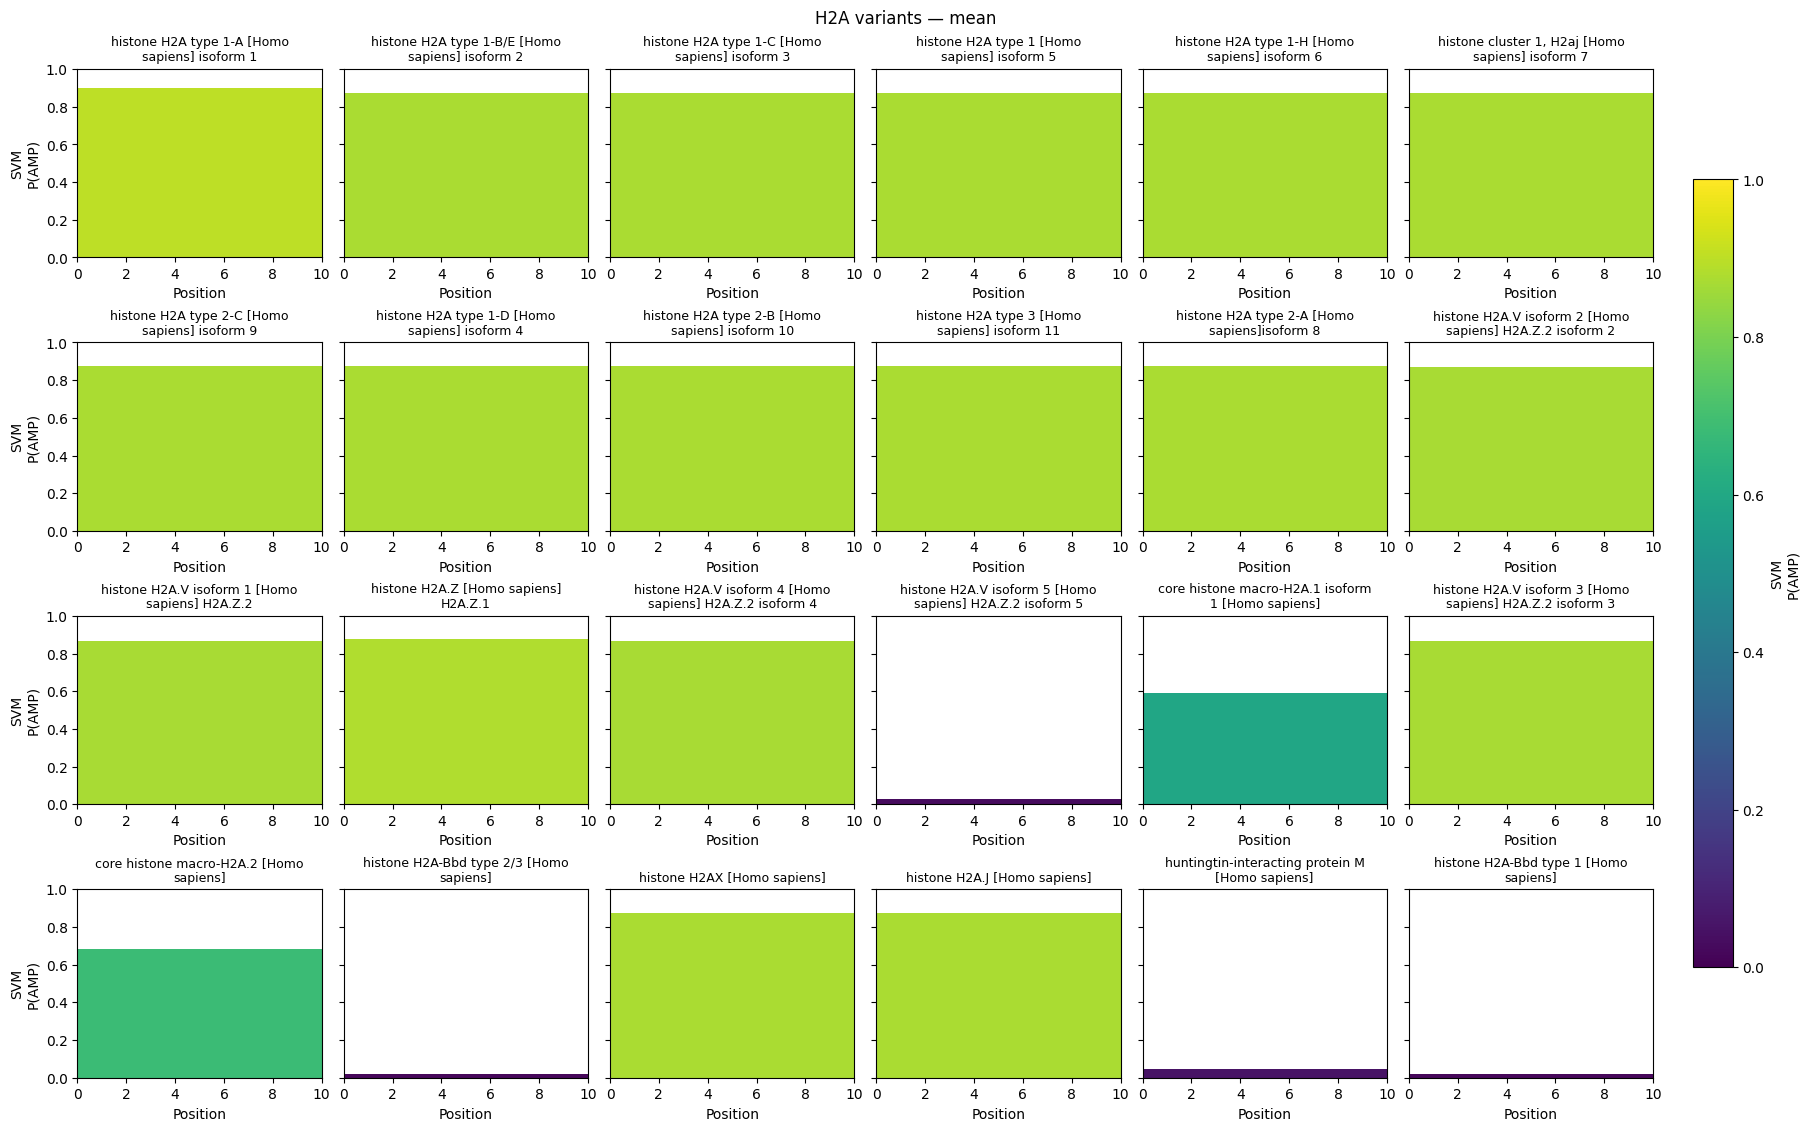

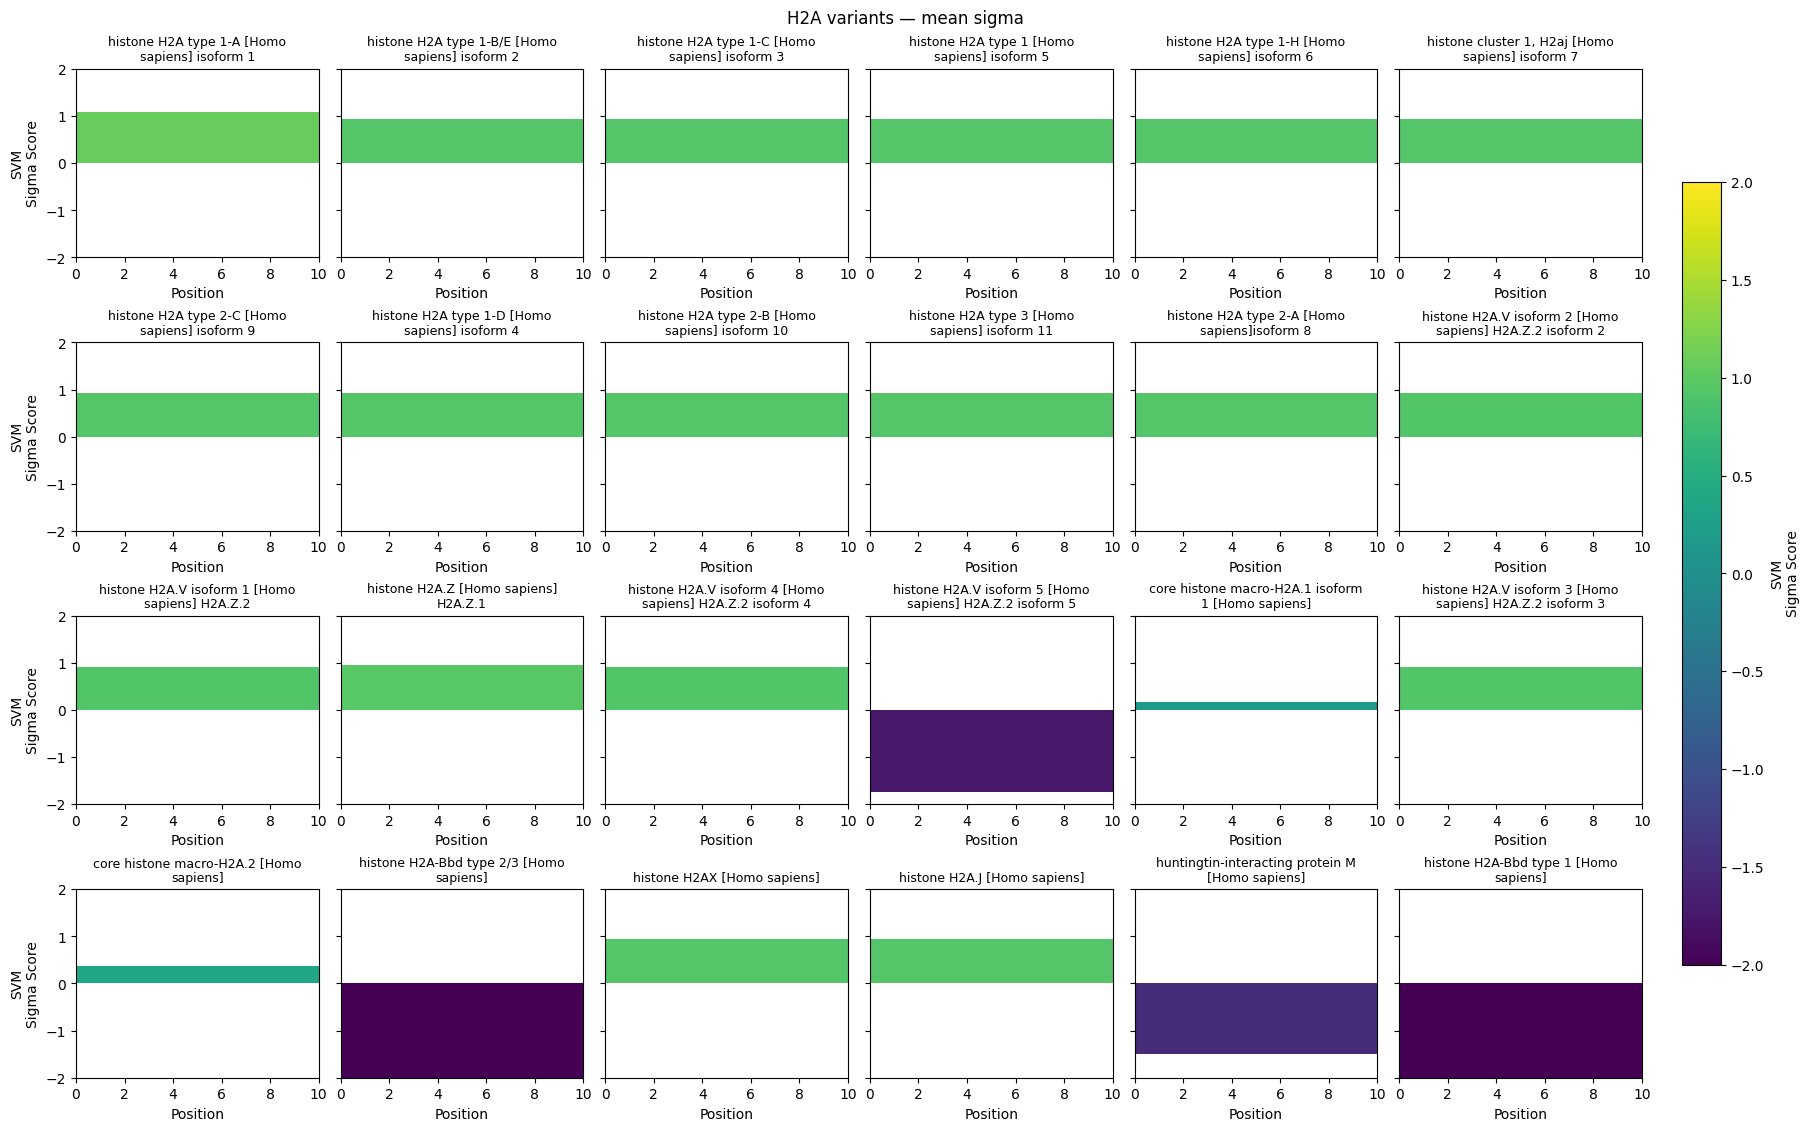

In [5]:
def select_profiles(frame: pd.DataFrame, sequence_ids: list[str] | None, limit: int | None) -> pd.DataFrame:
    if sequence_ids is None:
        return frame.iloc[:limit]
    selected = frame[frame["id"].astype(str).isin(sequence_ids)]
    missing = sorted(set(sequence_ids) - set(selected["id"].astype(str)))
    if missing:
        raise ValueError(f"Unknown sequence IDs: {', '.join(missing)}")
    return selected


selected_profiles = select_profiles(profiles, SEQUENCE_IDS, MAX_SEQUENCES)
if selected_profiles.empty:
    raise ValueError("No sequence profiles selected.")

plot_metric_grid(
    selected_profiles,
    "p_amp_mean_profile",
    "SVM\nP(AMP)",
    PLOT_TITLE,
    plt.Normalize(vmin=0.0, vmax=1.0),
    ylim=(0.0, 1.0),
)
sigma_norm = symmetric_sigma_norm(selected_profiles)
plot_metric_grid(
    selected_profiles,
    "hyperplane_distance_mean_profile",
    "SVM\nSigma Score",
    f"{PLOT_TITLE} sigma",
    sigma_norm,
    ylim=(sigma_norm.vmin, sigma_norm.vmax),
)